# JAWAD HASSAN
# 2230-0035
# BS AI
# ML
# LAB MID

In [42]:
#libraries used
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score,accuracy_score, precision_score, recall_score
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

## Question 1: Regression Analysis
## Part A: Data Understanding & Pre processing

In [13]:

#dataset 1 Concrete Comprehensive Strength
#1.load data
df = pd.read_csv("/Users/macbook/Desktop/sem6/ML/mid/gitmid/Concrete_Data.csv")
print("Rows and Columns:", df.shape)
print("\nData Types:\n", df.dtypes)

Rows and Columns: (1030, 9)

Data Types:
 Cement (component 1)(kg in a m^3 mixture)                float64
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    float64
Fly Ash (component 3)(kg in a m^3 mixture)               float64
Water  (component 4)(kg in a m^3 mixture)                float64
Superplasticizer (component 5)(kg in a m^3 mixture)      float64
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     float64
Fine Aggregate (component 7)(kg in a m^3 mixture)        float64
Age (day)                                                  int64
Concrete compressive strength(MPa, megapascals)          float64
dtype: object


In [14]:
#2.Rename columns
df.columns = ['Cement', 'BlastFurnace_Slag', 'Fly_Ash', 'Water', 'Superplasticizer', 
              'Coarse_Aggregate', 'Fine_Aggregate', 'Age', 'Strength']
print("\nFirst 5 rows after renaming:\n", df.head())


First 5 rows after renaming:
    Cement  BlastFurnace_Slag  Fly_Ash  Water  Superplasticizer  \
0   540.0                0.0      0.0  162.0               2.5   
1   540.0                0.0      0.0  162.0               2.5   
2   332.5              142.5      0.0  228.0               0.0   
3   332.5              142.5      0.0  228.0               0.0   
4   198.6              132.4      0.0  192.0               0.0   

   Coarse_Aggregate  Fine_Aggregate  Age  Strength  
0            1040.0           676.0   28     79.99  
1            1055.0           676.0   28     61.89  
2             932.0           594.0  270     40.27  
3             932.0           594.0  365     41.05  
4             978.4           825.5  360     44.30  


In [ ]:
# 3.Check for missing values
print("\nMissing values per column:\n", df.isnull().sum())
#we have no null values but we have 0 values in some columns which is not possible for our dataset so we will replace those 0 values with mean of the column
# Replace 0 values with mean
columns_to_replace = ['Cement', 'BlastFurnace_Slag', 'Fly_Ash', 'Water', 'Superplasticizer', 'Coarse_Aggregate', 'Fine_Aggregate']
for col in columns_to_replace:
    mean_value = df[col].mean()
    df[col] = df[col].replace(0, mean_value)
print("\nFirst 5 rows after replacing 0 values:\n", df.head())


Missing values per column:
 Cement               0
BlastFurnace_Slag    0
Fly_Ash              0
Water                0
Superplasticizer     0
Coarse_Aggregate     0
Fine_Aggregate       0
Age                  0
Strength             0
dtype: int64

First 5 rows after replacing 0 values:
    Cement  BlastFurnace_Slag   Fly_Ash  Water  Superplasticizer  \
0   540.0          73.895825  54.18835  162.0           2.50000   
1   540.0          73.895825  54.18835  162.0           2.50000   
2   332.5         142.500000  54.18835  228.0           6.20466   
3   332.5         142.500000  54.18835  228.0           6.20466   
4   198.6         132.400000  54.18835  192.0           6.20466   

   Coarse_Aggregate  Fine_Aggregate  Age  Strength  
0            1040.0           676.0   28     79.99  
1            1055.0           676.0   28     61.89  
2             932.0           594.0  270     40.27  
3             932.0           594.0  365     41.05  
4             978.4           825.5  360  

In [18]:
#4. Unique values for Age
print("\nUnique values in Age:", df['Age'].nunique())
#It tells us that the concrete was tested at specific, standardized time intervals (like 7, 14, or 28 days) rather than being measured continuously.


Unique values in Age: 14


In [ ]:
#5. Apply feature scaling on the input features
# The input features are the first 8 columns (all except 'Strength')
x = df.drop('Strength', axis=1)
y = df['Strength']
scaler = MinMaxScaler()

# Fit and transform the input features
X_scaled = scaler.fit_transform(x)

# Convert the scaled array back to a DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=x.columns)

# Display the first 5 rows of the scaled input features
print(X_scaled_df.head())

#explaination of feature scaling: 
# Scaling is necessary for distance-based or regularized regression models (like SVR, Ridge, or Lasso) to ensure features with larger magnitudes don't dominate the model,
# but it is not required for simple linear regression or tree-based algorithms.

     Cement  BlastFurnace_Slag   Fly_Ash     Water  Superplasticizer  \
0  1.000000           0.180528  0.169068  0.321086          0.026230   
1  1.000000           0.180528  0.169068  0.321086          0.026230   
2  0.526256           0.377440  0.169068  0.848243          0.147694   
3  0.526256           0.377440  0.169068  0.848243          0.147694   
4  0.220548           0.348450  0.169068  0.560703          0.147694   

   Coarse_Aggregate  Fine_Aggregate       Age  
0          0.694767        0.205720  0.074176  
1          0.738372        0.205720  0.074176  
2          0.380814        0.000000  0.739011  
3          0.380814        0.000000  1.000000  
4          0.515698        0.580783  0.986264  


## Part B: Visualization & Model Selection

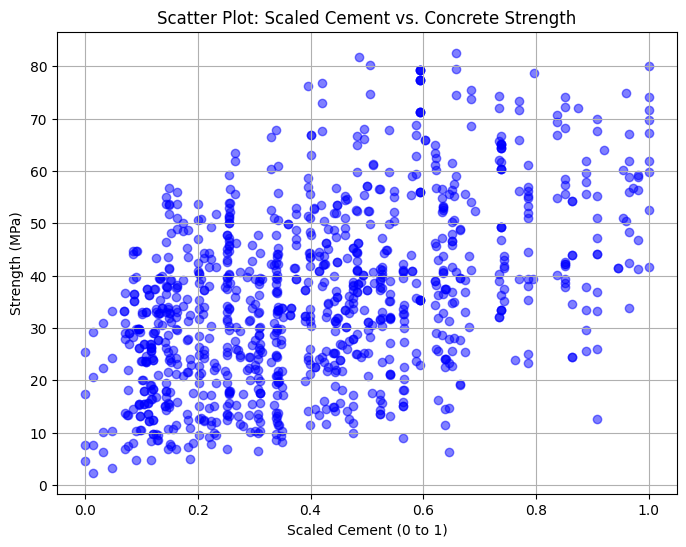

In [22]:
#1. Plot a scatter plot of Cement vs Strength.
# Using the scaled dataframe 'X_scaled_df'
plt.figure(figsize=(8, 6))

# Plotting Scaled Cement vs Original Strength
plt.scatter(X_scaled_df['Cement'], df['Strength'], alpha=0.5, color='blue')

plt.title('Scatter Plot: Scaled Cement vs. Concrete Strength')
plt.xlabel('Scaled Cement (0 to 1)')
plt.ylabel('Strength (MPa)')
plt.grid(True)
plt.show()  

### Analyze
### Does the relationship appear linear or non-linear?
### Ans. The relationship appear non-linear
### Based on your observation, which regression model do you think will perform better (Linear Regression or Polynomial Regression)?
### Ans. Polynomial Regression will perform better
### Give a clear reasoning for your choice
### Ans. Simple Linear Regression will attempt to draw a single, rigid straight line through the data, which will fail to capture the wide spread and varying density of the points. Polynomial Regression provides the flexibility to curve and better fit the complex, non-linear pattern of the data.

### Part C: Model Training & Comparative Analysis

In [24]:
#1
#split
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

# Linear Regression model
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# evaluate
print("Linear Regression")
print(f"MSE: {mean_squared_error(y_test, y_pred_lr):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.4f}")
print(f"R² Score: {r2_score(y_test, y_pred_lr):.4f}\n")

Linear Regression
MSE: 102.3774
MAE: 8.0682
R² Score: 0.6027



In [ ]:
#2. polynomial regression 
# Polynomial Regression (Degree = 2) 
poly_2 = PolynomialFeatures(degree=2)
X_train_poly2 = poly_2.fit_transform(X_train)
X_test_poly2 = poly_2.transform(X_test)

lr_poly2 = LinearRegression()
lr_poly2.fit(X_train_poly2, y_train)
y_pred_poly2 = lr_poly2.predict(X_test_poly2)
# evaluate
print(" Polynomial Regression (Degree = 2)")
print(f"MSE: {mean_squared_error(y_test, y_pred_poly2):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_poly2):.4f}")
print(f"R² Score: {r2_score(y_test, y_pred_poly2):.4f}\n")

# Polynomial Regression (Degree = 3) 
poly_3 = PolynomialFeatures(degree=3)
X_train_poly3 = poly_3.fit_transform(X_train)
X_test_poly3 = poly_3.transform(X_test)

lr_poly3 = LinearRegression()
lr_poly3.fit(X_train_poly3, y_train)
y_pred_poly3 = lr_poly3.predict(X_test_poly3)
# evaluate
print("Polynomial Regression (Degree = 3)")
print(f"MSE: {mean_squared_error(y_test, y_pred_poly3):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_poly3):.4f}")
print(f"R² Score: {r2_score(y_test, y_pred_poly3):.4f}")


 Polynomial Regression (Degree = 2)
MSE: 63.6588
MAE: 6.4836
R² Score: 0.7530

Polynomial Regression (Degree = 3)
MSE: 55.4329
MAE: 5.1135
R² Score: 0.7849


### # Degree 3 is performing better than degree 2 and linear regression as it has lower MSE and MAE and higher R² score.

In [29]:
#3. table

# Create a dictionary to store the results
results_data = {
    'Model': ['Linear Regression', 'Polynomial (deg=2)', 'Polynomial (deg=3)'],
    
    'MSE': [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_poly2),
        mean_squared_error(y_test, y_pred_poly3)
    ],
    
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_poly2),
        mean_absolute_error(y_test, y_pred_poly3)
    ],
    
    'R² Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_poly2),
        r2_score(y_test, y_pred_poly3)
    ]
}

# Convert the dictionary into a pandas DataFrame
comparison_df = pd.DataFrame(results_data)

# Round the values to 4 decimal places for cleaner display
comparison_df = comparison_df.round(4)

# Display the table
print(comparison_df.to_string(index=False))

             Model      MSE    MAE  R² Score
 Linear Regression 102.3774 8.0682    0.6027
Polynomial (deg=2)  63.6588 6.4836    0.7530
Polynomial (deg=3)  55.4329 5.1135    0.7849


### 4. Conceptual Question
### Both Ridge and Lasso regression solve the problem of overfitting (and handle multicollinearity) in standard Linear Regression by adding a penalty term that restricts the model from learning overly complex patterns
### Key difference
### Ridge Regression: It adds a penalty equal to the squared magnitude of coefficients, which shrinks all features' coefficients toward zero to reduce their impact, but never makes them exactly zero.
### Lasso Regression: It adds a penalty equal to the absolute magnitude of coefficients, which can shrink less important feature coefficients exactly to zero, effectively performing built-in feature selection.

### Question 2: Dimensionality Reduction, PCA & LDA

### Part A: Principal Component Analysis (PCA)

In [ ]:
# Dataset Mobile Price Classification
# 1. Load the dataset
df= pd.read_csv("/Users/macbook/Desktop/sem6/ML/mid/gitmid/mobileprice.csv")
columns = df.columns.tolist()
print("Features:", columns[:-1])
print("Target:", columns[-1])

# 2. Check for missing values
print("Total missing values:", df.isnull().sum().sum())
#no missing values


Features: ['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi']
Target: price_range
Total missing values: 0


### PCA
### PCA maximizes variance to find important patterns, so if features aren't scaled, those with naturally large numbers (like battery power) will mathematically dominate the results. Scaling ensures all features have an equal baseline.

PCA 2 Components Shape: (2000, 2)
PCA 2 Components Variance Ratio: [0.13258747 0.09960955]

PCA 3 Components Shape: (2000, 3)
PCA 3 Components Variance Ratio: [0.13258747 0.09960955 0.09820247]


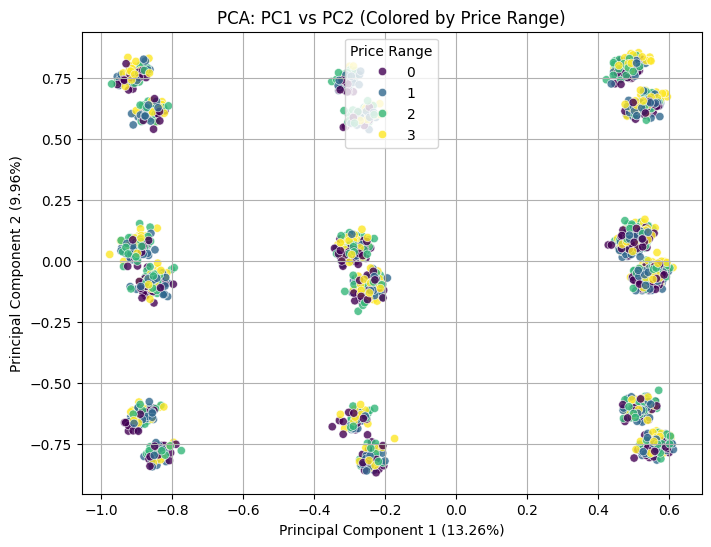

In [33]:
# Separate features and target
X = df.drop('price_range', axis=1)
y = df['price_range']

# 2. Apply MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply PCA (2 Components)
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)
print("PCA 2 Components Shape:", X_pca2.shape)
print("PCA 2 Components Variance Ratio:", pca2.explained_variance_ratio_)

# Apply PCA (3 Components)
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)
print("\nPCA 3 Components Shape:", X_pca3.shape)
print("PCA 3 Components Variance Ratio:", pca3.explained_variance_ratio_)

# 4. Plot PCA result (PC1 vs PC2)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca2[:, 0], y=X_pca2[:, 1], hue=y, palette='viridis', alpha=0.8)
plt.title('PCA: PC1 vs PC2 (Colored by Price Range)')
plt.xlabel(f'Principal Component 1 ({pca2.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca2.explained_variance_ratio_[1]*100:.2f}%)')
plt.legend(title='Price Range')
plt.grid(True)
plt.show()

### Are the price range classes well-separated or overlapping in the PCA plot?
### The price range classes are highly overlapping, forming a dense, mixed cloud without any distinct clusters.There is no clear linear separation between the four categories in this 2D principal component space.
### What does this tell you about using PCA for separating mobile price categories?
### This tells us PCA is ineffective for this task because it is unsupervised and ignores class labels, resulting in heavily overlapping categories. Instead, supervised techniques like Linear Discriminant Analysis (LDA) should be used, as they explicitly aim to maximize the separation between these distinct price classes.

### Part B: Linear Discriminant Analysis (LDA)

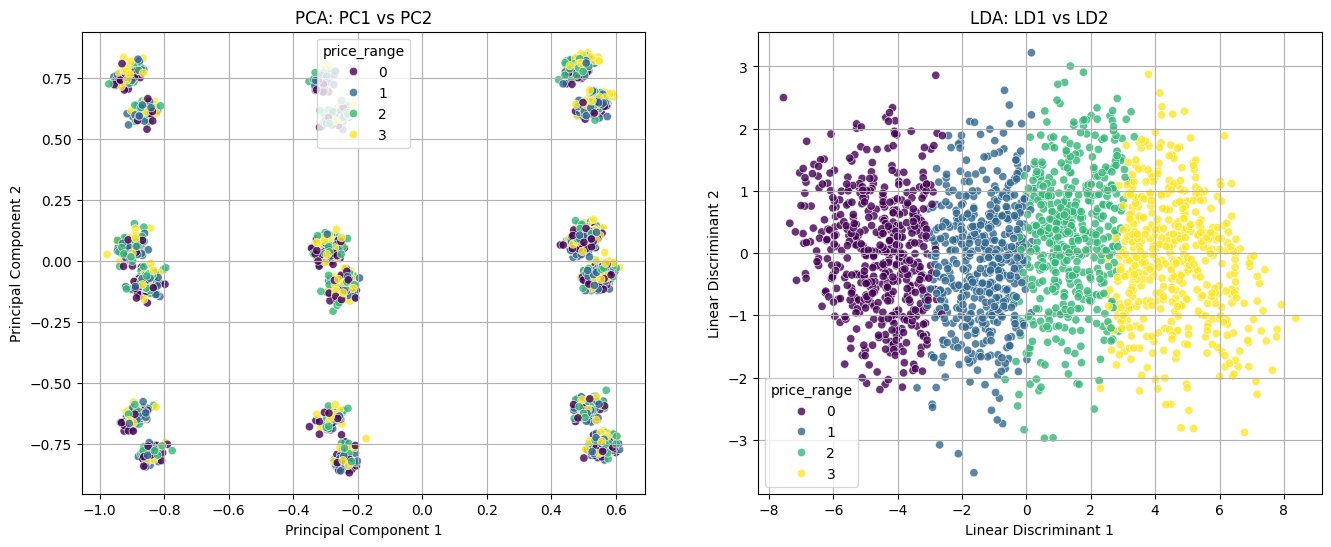

In [39]:
# 1. apply LDA 
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)  # LDA requires the target 'y'

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA Plot
sns.scatterplot(x=X_pca2[:, 0], y=X_pca2[:, 1], hue=y, palette='viridis', alpha=0.8, ax=axes[0])
axes[0].set_title('PCA: PC1 vs PC2')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].grid(True)

# LDA Plot
sns.scatterplot(x=X_lda[:, 0], y=X_lda[:, 1], hue=y, palette='viridis', alpha=0.8, ax=axes[1])
axes[1].set_title('LDA: LD1 vs LD2')
axes[1].set_xlabel('Linear Discriminant 1')
axes[1].set_ylabel('Linear Discriminant 2')
axes[1].grid(True)

plt.show()

### In which plot are the price range classes more clearly separate
### Ans. In lda plot price range classes more clearly separated

## Part C: Conceptual Questions
### 1. What does Explained Variance Ratio tell you in PCA? If PC1 = 0.62 and PC2 = 0.18, how much total variance is captured by 2 components?
### The Explained Variance Ratio tells you the proportion (or percentage) of the original dataset's total information (variance) that is successfully captured by a single principal component. It helps you understand how much information you retain when you reduce dimensions.
### Total variance captured: If PC1 = 0.62 and PC2 = 0.18, the total variance captured by these 2 components is 0.62 + 0.18 = 0.80 (or 80%).
### 2. The Mobile Price dataset has 4 price range classes and 20 features. What is the max number of components LDA can produce from this dataset?
### The maximum number of components LDA can produce from this dataset is 3.
### Reasoning: In LDA, the maximum number of components you can extract is strictly limited to the number of classes minus one (C - 1)

### Question 3: KNN + Random Forest Classification
### Part A: Classification : KNN & Random Forest

In [44]:
#Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Helper function to evaluate and print metrics
def evaluate(model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred, average='macro'):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred, average='macro'):.4f}\n")

#1. Apply Models
print("--- KNN (K=3) ---")
evaluate(KNeighborsClassifier(n_neighbors=3))

print("--- KNN (K=57) ---")
evaluate(KNeighborsClassifier(n_neighbors=57))
# 2.random forest
print("--- Random Forest ---")
evaluate(RandomForestClassifier(random_state=42))

--- KNN (K=3) ---
Accuracy: 0.3850
Precision: 0.4018
Recall: 0.3779

--- KNN (K=57) ---
Accuracy: 0.5200
Precision: 0.5414
Recall: 0.5154

--- Random Forest ---
Accuracy: 0.8925
Precision: 0.8916
Recall: 0.8914



### k=57 gives best result as it has better accuracy, recall, precision. K=57 smooths out the decision boundaries and generalizes much better on the test set.

In [ ]:
# table
def evaluate(model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    return acc, prec, rec
results = []

models = [
    ("KNN (K=3)", KNeighborsClassifier(n_neighbors=3)),
    ("KNN (K=57)", KNeighborsClassifier(n_neighbors=57)),
    ("Random Forest", RandomForestClassifier(random_state=42))
]

for name, model in models:
    acc, prec, rec = evaluate(model)
    results.append([name, acc, prec, rec])

df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall"])
print(df)

           Model  Accuracy  Precision    Recall
0      KNN (K=3)    0.3850   0.401840  0.377917
1     KNN (K=57)    0.5200   0.541413  0.515369
2  Random Forest    0.8925   0.891633  0.891418


### out of 3 random forest performs best overall

### Part B: Conceptual Evaluation
### 1.
### What does Recall tell you about a model's performance?
### Ans. Recall (Sensitivity) measures the proportion of actual positive cases that were correctly identified by the model. It indicates the model's ability to "find" all relevant instances without missing them (minimizing False Negatives).
### What does Precision tell you about a model's performance?
### Ans. Precision measures the proportion of predicted positive cases that were actually correct. It indicates the model's accuracy when it claims a result is positive (minimizing False Positives).
### If you had to choose one model for detecting a disease (where missing a positive case is very costly), which would you choose and why
### Why does Random Forest generally perform better than single Decision Tree? Explain in 2–3 lines.
### Ans. I would choose the Random Forest model (the one with higher Recall).
### Reasoning: In disease detection, the cost of a "False Negative" (missing a sick patient) is much higher than a "False Positive" (testing a healthy person further). High Recall ensures that almost everyone with the disease is caught, which is critical for life-saving treatments.
### 2. Why Random Forest performs better than a single Decision Tree
### Ans. Random Forest is an ensemble method that combines the predictions of many individual decision trees through a process called bagging (Bootstrap Aggregating). While a single decision tree is prone to high variance and overfitting to noise, Random Forest reduces this error by averaging multiple independent trees trained on different subsets of data and features, resulting in a more robust and accurate model.